# Chapter 17 -- Mathematical Modeling

> **Prerequisites:** ch001-ch016
>
> **You will learn:**
> - The complete modeling cycle: observe, abstract, solve, validate, refine
> - How to choose between competing model types for a situation
> - Model validation: when is a model good enough, and for what?
> - How to make model assumptions explicit and testable
>
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

Mathematical modeling is the full cycle of translating a real-world situation into mathematics, extracting insight, and translating back. Chapter 3 introduced the four-stage pipeline. This chapter treats modeling as a discipline.

**The complete modeling cycle:**

  Real world -> Observe -> Simplify -> Abstract -> Mathematical model
                                                         |
                                                       Solve
                                                         |
  Real world <- Interpret <- Validate <- Analyze <- Solution

The cycle does not stop at one pass. A model's predictions are compared to reality. Where they fail, the model is refined.

**What makes a model good:**
- *Accuracy:* Predictions match observed data within tolerance
- *Tractability:* The mathematics is solvable
- *Interpretability:* Parameters mean something in the original domain
- *Generalizability:* Predictions hold outside the training data range

These four goals conflict. A very accurate model is often intractable. There is no single best model -- only models appropriate for specific use cases.

**Common misconception:** A model with more parameters is better.

More parameters improve fit on observed data but often hurt generalization (ch003 overfitting). The principle of parsimony: prefer the simplest model adequate for the task.

## 2. Intuition & Mental Models

**Physical analogy:** Climate vs weather models. A global climate model has millions of coupled equations. A local forecast uses a simpler model tuned for 48-hour accuracy. Neither is "the right model" -- they serve different questions.

**Computational analogy:** Microservices vs monolith. Neither is universally better; the choice depends on requirements. The modeling choice makes the same tradeoff between accuracy and tractability.

Recall from ch003 *(Abstraction and Modeling)*: we built the four-stage pipeline and showed overfitting with polynomial degree. This chapter adds the validation loop and explicit assumption tracking.

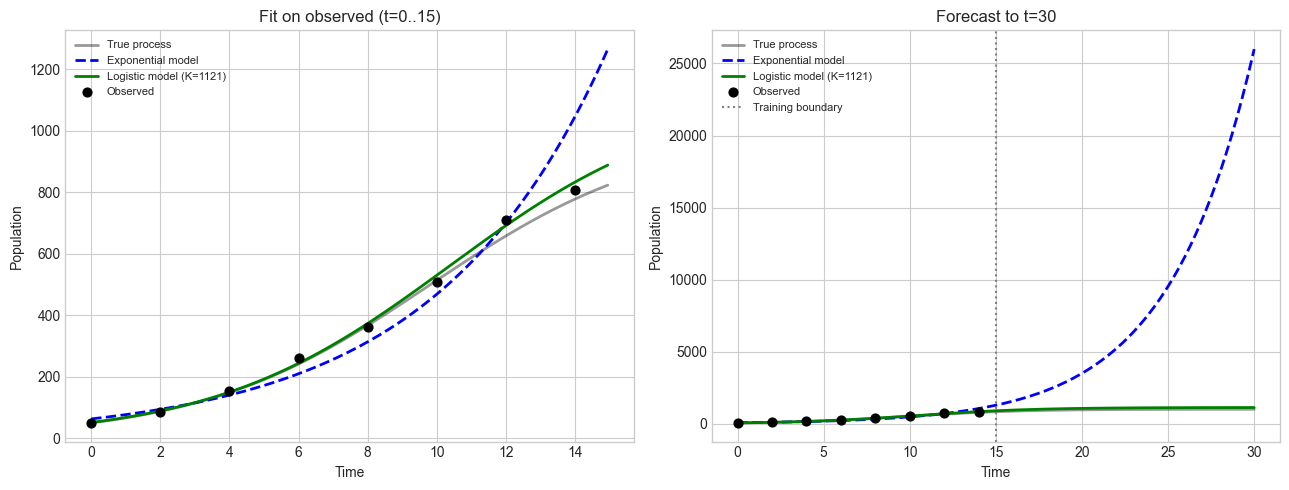

Both models fit training data well.
Exponential diverges on extrapolation. Logistic respects carrying capacity.


In [1]:
# --- Visualization: Two models fit well in-sample but diverge out-of-sample ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)
K, r0, P0 = 1000.0, 0.3, 50.0
t_true = np.linspace(0, 30, 300)
P_true = K / (1 + ((K - P0) / P0) * np.exp(-r0 * t_true))

t_obs = np.arange(0, 16, 2, dtype=float)
P_obs = K / (1 + ((K - P0)/P0)*np.exp(-r0*t_obs)) * (1 + 0.05*np.random.randn(len(t_obs)))

# Fit exponential to observed data
log_P = np.log(np.maximum(P_obs, 1))
coeffs_exp = np.polyfit(t_obs, log_P, 1)

# Fit logistic (grid search)
best_err, best_K, best_r = np.inf, 1000.0, 0.3
for K_try in np.linspace(500, 2000, 30):
    for r_try in np.linspace(0.1, 0.8, 30):
        P_pred = K_try / (1+((K_try-P_obs[0])/P_obs[0])*np.exp(-r_try*t_obs))
        err = np.sum((P_pred-P_obs)**2)
        if err < best_err:
            best_err, best_K, best_r = err, K_try, r_try

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (title, show_future) in zip(axes, [('Fit on observed (t=0..15)', False),
                                             ('Forecast to t=30', True)]):
    t_plot = t_true if show_future else t_true[t_true<=15]
    mask = t_true <= (30 if show_future else 15)
    ax.plot(t_plot, P_true[mask], 'k-', lw=2, alpha=0.4, label='True process')
    ax.plot(t_plot, np.exp(coeffs_exp[1])*np.exp(coeffs_exp[0]*t_plot),
            'b--', lw=2, label='Exponential model')
    ax.plot(t_plot, best_K/(1+((best_K-P_obs[0])/P_obs[0])*np.exp(-best_r*t_plot)),
            'g-', lw=2, label=f'Logistic model (K={best_K:.0f})')
    ax.scatter(t_obs, P_obs, color='black', s=40, zorder=5, label='Observed')
    if show_future:
        ax.axvline(15, color='gray', linestyle=':', label='Training boundary')
    ax.set_xlabel('Time'); ax.set_ylabel('Population')
    ax.set_title(title); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()
print("Both models fit training data well.")
print("Exponential diverges on extrapolation. Logistic respects carrying capacity.")

## 4. Mathematical Formulation

**Model validation criterion:**

Given model M, training data {(t_i, y_i)}, and test data {(t_j*, y_j*)}:

  Training error E_train = (1/n) * sum (M(t_i) - y_i)^2
  Test error    E_test  = (1/m) * sum (M(t_j*) - y_j*)^2

A model is validated when E_test is within acceptable tolerance epsilon. If E_train << E_test, the model has overfit.

**Assumption audit:** For each assumption A_i:
- What is the consequence if A_i is violated?
- Over what range is A_i approximately satisfied?
- Can the model remove A_i without becoming intractable?

In [2]:
# --- Implementation: Model with explicit assumption tracking ---
import numpy as np

class DocumentedModel:
    def __init__(self, name, description):
        self.name = name; self.description = description
        self.assumptions = []; self.params = {}
        self.fit_range = None; self.train_rmse = None; self.test_rmse = None
        self._predict_fn = None
    
    def add_assumption(self, assumption, consequence, valid_range='unknown'):
        self.assumptions.append({'assumption': assumption,
                                  'consequence': consequence, 'valid_range': valid_range})
        return self
    
    def set_predict_fn(self, fn):
        self._predict_fn = fn; return self
    
    def fit(self, t_train, y_train):
        self.fit_range = (t_train.min(), t_train.max())
        preds = self._predict_fn(t_train)
        self.train_rmse = np.sqrt(np.mean((y_train - preds)**2))
        return self
    
    def validate(self, t_test, y_test):
        preds = self._predict_fn(t_test)
        self.test_rmse = np.sqrt(np.mean((y_test - preds)**2))
        return self
    
    def report(self):
        print(f"Model: {self.name}")
        print(f"Assumptions:")
        for i, a in enumerate(self.assumptions, 1):
            print(f"  {i}. {a['assumption']}")
            print(f"     If violated: {a['consequence']}")
        print(f"Training RMSE: {self.train_rmse:.4f}")
        if self.test_rmse is not None:
            ratio = self.test_rmse / self.train_rmse
            status = 'OK' if ratio < 2 else 'POSSIBLE OVERFIT'
            print(f"Test RMSE:     {self.test_rmse:.4f}  (ratio {ratio:.2f} -- {status})")

np.random.seed(42)
t_all = np.arange(0, 31, 2, dtype=float)
P_all = 1000/(1+(950/50)*np.exp(-0.3*t_all)) * (1+0.05*np.random.randn(len(t_all)))
t_train, y_train = t_all[:8], P_all[:8]
t_test,  y_test  = t_all[8:], P_all[8:]

m = DocumentedModel('Logistic Population Model', 'P(t) = K / (1 + (K-P0)/P0 * exp(-r*t))')
m.add_assumption('Population grows proportionally to current size',
                  'Underestimates growth if food supply increases', 'Stable environment')
m.add_assumption('Carrying capacity K is constant',
                  'Fails when environment changes', 'Short timescales')
m.set_predict_fn(lambda t: 1000/(1+19*np.exp(-0.3*t)))
m.fit(t_train, y_train).validate(t_test, y_test)
m.report()

Model: Logistic Population Model
Assumptions:
  1. Population grows proportionally to current size
     If violated: Underestimates growth if food supply increases
  2. Carrying capacity K is constant
     If violated: Fails when environment changes
Training RMSE: 22.3926
Test RMSE:     49.1887  (ratio 2.20 -- POSSIBLE OVERFIT)


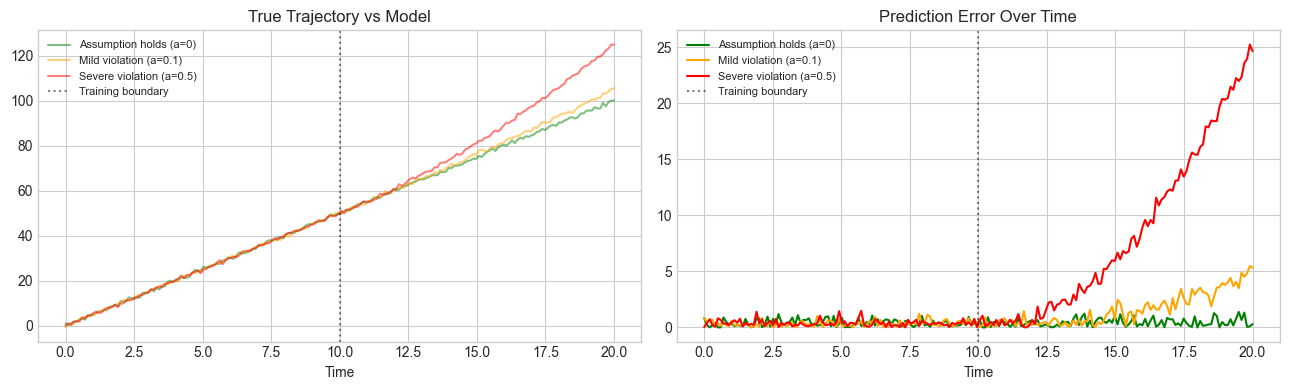

In [3]:
# --- Experiment: Effect of assumption violations ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

t = np.linspace(0, 20, 200)
np.random.seed(7)
V0, X0 = 5.0, 0.0

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for label, accel, color in [
    ('Assumption holds (a=0)', 0.0, 'green'),
    ('Mild violation (a=0.1)', 0.1, 'orange'),
    ('Severe violation (a=0.5)', 0.5, 'red'),
]:
    noise = 0.5*np.random.randn(len(t))
    x_true = X0 + V0*t + 0.5*accel*np.maximum(t-10, 0)**2 + noise
    t_train_mask = t <= 10
    v_fit = np.polyfit(t[t_train_mask], x_true[t_train_mask], 1)[0]
    x_pred = X0 + v_fit*t
    axes[0].plot(t, x_true, alpha=0.5, color=color, lw=1.5, label=label)
    axes[1].plot(t, np.abs(x_true - x_pred), color=color, lw=1.5, label=label)

for ax in axes:
    ax.axvline(10, color='black', linestyle=':', alpha=0.5, label='Training boundary')
    ax.legend(fontsize=8)

axes[0].set_title('True Trajectory vs Model'); axes[0].set_xlabel('Time')
axes[1].set_title('Prediction Error Over Time'); axes[1].set_xlabel('Time')
plt.tight_layout(); plt.show()

## 7. Exercises

**Easy 1.** For the logistic model P(t) = K / (1 + (K-P0)/P0 * e^(-rt)), identify three explicit assumptions. For each, describe a real population where it would fail.

**Easy 2.** A pendulum model assumes small-angle: theta(t) = A*cos(omega*t) with omega = sqrt(g/L). At what angle does sin(theta) approx theta introduce more than 1% error? Find numerically.

**Medium 1.** Simulate the SIR epidemic model (S, I, R compartments) using Euler's method with beta=0.3, gamma=0.1, N=1000, I(0)=1. Plot all three compartments. Find the time of peak infection.

**Medium 2.** Fit linear, quadratic, and exponential models to house price vs size data (generate synthetic data). Compare training RMSE and extrapolation behavior. Which model would you deploy and why?

**Hard.** Build a complete modeling workflow for hourly temperature data: (1) explicit assumptions, (2) two competing structures, (3) proper train/test split, (4) DocumentedModel instances, (5) RMSE comparison, (6) deployment recommendation.

In [4]:
# --- Mini Project: Competing model comparison ---
import numpy as np

np.random.seed(42)
t = np.linspace(0, 50, 100)
y = 315 + 1.5*t + 5*np.sin(2*np.pi*t/10) + np.random.randn(len(t))
split = 80
t_tr, y_tr, t_te, y_te = t[:split], y[:split], t[split:], y[split:]

models = [
    ('Linear trend',
     lambda t,y: np.polyfit(t, y, 1),
     lambda t,p: np.polyval(p, t)),
    ('Quadratic',
     lambda t,y: np.polyfit(t, y, 2),
     lambda t,p: np.polyval(p, t)),
    ('Linear + seasonal',
     lambda t,y: np.linalg.lstsq(
         np.column_stack([t, np.sin(2*np.pi*t/10), np.ones_like(t)]), y, rcond=None)[0],
     lambda t,p: p[0]*t + p[1]*np.sin(2*np.pi*t/10) + p[2]),
]

print(f"{'Model':<22} {'Train RMSE':>12} {'Test RMSE':>12}")
print('-' * 48)
for name, fit_fn, pred_fn in models:
    params = fit_fn(t_tr, y_tr)
    train_rmse = np.sqrt(np.mean((pred_fn(t_tr, params) - y_tr)**2))
    test_rmse  = np.sqrt(np.mean((pred_fn(t_te, params) - y_te)**2))
    print(f"{name:<22} {train_rmse:>12.4f} {test_rmse:>12.4f}")

Model                    Train RMSE    Test RMSE
------------------------------------------------
Linear trend                 3.6802       3.8996
Quadratic                    3.6784       3.8396
Linear + seasonal            0.9454       0.6602


## 9. Chapter Summary & Connections

- Mathematical modeling is a cycle: observe -> abstract -> solve -> validate -> refine
- Model quality has four dimensions: accuracy, tractability, interpretability, generalizability
- Explicit assumption tracking determines where a model applies and where it breaks
- Domain knowledge -- not just fit quality -- should drive model structure selection

**Forward:** The comparison framework scales to ch283 -- Model Evaluation in Part IX. The logistic growth model reappears in ch080 -- Logistic Growth Simulation.

**Backward:** Operationalizes ch003 *(Abstraction and Modeling)* with explicit validation and competitive comparison.